# Real-world example: mapping planned fieldwork

A worked example of using [ccamlrgis](https://github.com/Zephyr-Sylvester/ccamlrgis-py)
for a real task, rather than a feature-by-feature tour: plotting planned
CCAMLR PREDYCT fieldwork sites on a CCAMLR-projected basemap, and building
publication-style comparison figures from it.

The source data (`data/planned-predyct-fieldwork.csv`) is fieldwork
planning information and isn't included in this repo -- see `.gitignore`.
To run this notebook end-to-end yourself, supply your own CSV with
`Location,Longitude,Latitude,Activity,Who` columns; `Latitude`/`Longitude`
may be blank for rows only known by a named place (e.g. "Gerlache
Strait"). The code below and its rendered output are a real run against
the actual (private) dataset -- what you're looking at is genuine output,
not a mockup.

This notebook builds up the same logic used by
`make_subarea48_fieldwork_by_country.py`, `make_subarea48_fieldwork_by_type.py`
and `make_subarea48_fieldwork_summary.py` (via the shared `fieldwork_common.py`)
step by step, explaining each `ccamlrgis`/`ccamlrgis.plot` call and the
design decisions around it, then assembles the same three figures.

In [1]:
import textwrap

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import pandas as pd

import ccamlrgis as cg
import ccamlrgis.plot as cgplot

CSV_PATH = "data/planned-predyct-fieldwork.csv"

## Loading the data

Nothing `ccamlrgis`-specific here -- just `pandas`, cleaned up for the
quirks real spreadsheet exports have: a UTF-8 BOM from Excel
(`encoding="utf-8-sig"`), stray whitespace in column names and string
columns, and `Longitude`/`Latitude` cells that are sometimes blank
(fieldwork known only by a named place, not GPS coordinates) or contain
non-numeric junk -- `pd.to_numeric(errors="coerce")` turns both into a
clean `NaN` rather than raising.

In [2]:
def load_fieldwork() -> pd.DataFrame:
    df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
    df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
    df["Location"] = df["Location"].str.strip()
    df["Who"] = df["Who"].str.strip()
    df["Activity"] = df["Activity"].str.strip()
    return df


fieldwork = load_fieldwork()
fieldwork.head()

,Location,Longitude,Latitude,Activity,Who
0,Shelf region from Gerlache Strait - Elephant I...,NaN,NaN,Krill biomass and ecosystem survey (RV Polarst...,Germany
1,Bransfield Strait - Elephant Island,NaN,NaN,Krill biomass surveys,Peru
2,South Orkney Islands,NaN,NaN,Krill biomass surveys,Norway
3,Shelf region from Gerlache Strait - Elephant I...,NaN,NaN,"Fisheries Acoustics (predator dives, krill swa...","Norway/HUBOcean, Chile, (China)"
4,Bransfield Strait,NaN,NaN,Glider-based krill biomass surveys,USA


## Projecting coordinates

`ccamlrgis` works in the CCAMLR standard CRS, EPSG:6932 (South Pole
Lambert Azimuthal Equal Area) -- the same convention as the R package.
`cg.project_data` takes a `DataFrame` of lat/lon columns and returns
projected `X`/`Y`; `append=False` returns just the new columns instead of
the lat/lon columns plus `X`/`Y`, which is all a single-point helper like
this needs.

In [3]:
def project(lat: float, lon: float) -> tuple[float, float]:
    out = cg.project_data(pd.DataFrame({"Lat": [lat], "Lon": [lon]}), names_in=["Lat", "Lon"], append=False)
    return float(out["X"].iloc[0]), float(out["Y"].iloc[0])


project(-64.5, -62.3333)  # Gerlache Strait

(-2500188.763695047, 1310775.3879441353)

## The basemap

`cgplot.basemap` sets up the Axes in EPSG:6932; everything else here is
plain `geopandas`/`ccamlrgis.plot` layered on top, cropped to Subareas
48.1/48.2 with a margin (`bounds`). `coast_land` is rasterized within
saved PDFs (`rasterized=True`) -- full-resolution coastline polygons
embedded as literal vector paths blow up PDF file size enormously for no
visible benefit at normal zoom; see `figure_io.save_fig`.

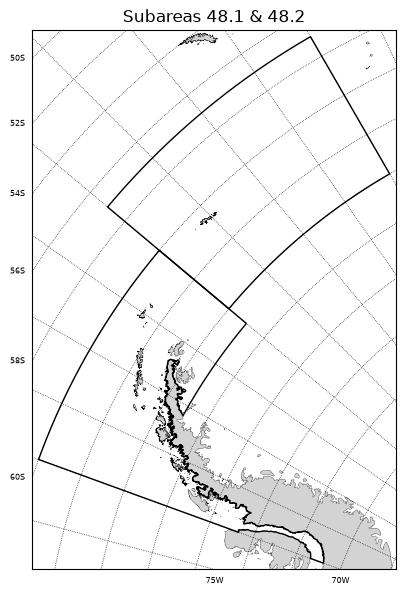

In [4]:
asds = cg.load_asds()
asds48 = asds[asds["GAR_Short_Label"].isin(["481", "482"])]
coast = cg.load_coastline()
coast_land = coast[coast["surface"] == "Land"]
bounds = tuple(asds48.buffer(30_000).total_bounds)


def draw_basemap(ax: plt.Axes) -> None:
    cgplot.basemap(ax=ax, xlim=(bounds[0], bounds[2]), ylim=(bounds[1], bounds[3]))
    coast_land.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.2, rasterized=True)
    asds48.boundary.plot(ax=ax, edgecolor="black", linewidth=1)
    cgplot.add_reference_grid(ax=ax, bounds=bounds, res_lat=2, res_lon=5, fontsize=6, linewidth=0.5)


fig, ax = plt.subplots(figsize=(6, 7))
draw_basemap(ax)
ax.set_title("Subareas 48.1 & 48.2")
plt.show()

## Approximate placements for named regions

Not every row has GPS coordinates -- some fieldwork is only described by
a named place ("Gerlache Strait", "Elephant Island"). `PLACE_COORDS` is a
small, **manually curated** lookup table: charted-position centres for
places we have a precise reference for, filled in by hand rather than
derived or eyeballed from other rows in the CSV, so they stay accurate
regardless of what else the CSV contains. This is a deliberate design
choice for this kind of exploratory/planning data -- there's no reliable
automatic way to turn "Gerlache Strait" into a single representative
point, so we don't pretend there is; a human decides and the decision is
visible and easy to update in one place.

In [5]:
PLACE_COORDS = {
    "Elephant Island": (-61.1333, -55.1167),  # 61 deg 08' S, 55 deg 07' W
    "Gerlache Strait": (-64.5000, -62.3333),  # 64 deg 30' 00" S, 62 deg 20' 00" W
    "Joinville Island": (-62.685, -54.941),
    "Bransfield Strait": (-63.183, -59.517),
    "South Orkney Islands": (-60.5, -45.9),
}


def _resolve_place(text: str) -> tuple[float, float] | None:
    """Exact match first, then substring containment -- so e.g. "Shelf
    region from Gerlache Strait" (half of a range like "Shelf region from
    Gerlache Strait - Elephant Island") still resolves via the "Gerlache
    Strait" entry instead of silently failing to match."""
    text = text.strip()
    if text in PLACE_COORDS:
        return PLACE_COORDS[text]
    for name, coord in PLACE_COORDS.items():
        if name in text:
            return coord
    return None

## Plotting one row

Three cases, in priority order:

1. **Precise coordinates** -> a filled circle.
2. **A range** ("Place A - Place B", e.g. a transect or survey corridor
   between two named places) -> a dashed line between their
   `PLACE_COORDS` positions.
3. **A single named place** with no coordinates -> an open star at its
   `PLACE_COORDS` position.

Every marker gets a small number instead of its full label, so sites
that cluster close together don't turn into overlapping walls of text;
the caller builds a numbered footnote list from each row's returned
string. Number labels use `patheffects.withStroke` to add a white halo,
so a red or orange number stays legible sitting on top of a similarly
dark marker or the coastline.

In [6]:
def _halo_annotate(ax: plt.Axes, text: str, xy: tuple[float, float], color: str) -> None:
    artist = ax.annotate(
        text, xy, color=color, fontsize=6, fontweight="bold",
        xytext=(4, 3), textcoords="offset points", zorder=6,
    )
    artist.set_path_effects([pe.withStroke(linewidth=2.2, foreground="white")])


def plot_row(ax: plt.Axes, row: pd.Series, number: int, label: str) -> str:
    lat, lon = row["Latitude"], row["Longitude"]
    location = row["Location"]

    if pd.notna(lat) and pd.notna(lon):
        x, y = project(lat, lon)
        ax.scatter([x], [y], marker="o", color="crimson", edgecolor="white", linewidth=0.5, s=42, zorder=5)
        _halo_annotate(ax, str(number), (x, y), color="crimson")
        return f"{number}. {label} ({location})"

    if " - " in location:
        a, b = (p.strip() for p in location.split(" - ", 1))
        pa, pb = _resolve_place(a), _resolve_place(b)
        if pa is not None and pb is not None:
            xa, ya = project(*pa)
            xb, yb = project(*pb)
            ax.plot([xa, xb], [ya, yb], linestyle="--", color="darkorange", linewidth=2, zorder=3)
            mx, my = (xa + xb) / 2, (ya + yb) / 2
            _halo_annotate(ax, str(number), (mx, my), color="darkorange")
            return f"{number}. {label} ({location}, approx.)"

    place = _resolve_place(location)
    if place is not None:
        x, y = project(*place)
        ax.scatter([x], [y], marker="*", facecolor="none", edgecolor="darkorange", linewidth=1.4, s=110, zorder=4)
        _halo_annotate(ax, str(number), (x, y), color="darkorange")
        return f"{number}. {label} ({location}, approx.)"

    return f"{number}. {label} ({location}, no coordinates)"

Try it on a handful of rows:

1. Krill biomass and ecosystem survey (RV Polarstern) (Shelf region from Gerlache Strait - Elephant Island, approx.)
2. Krill biomass surveys (Bransfield Strait - Elephant Island, approx.)
3. Krill biomass surveys (South Orkney Islands, approx.)
4. Fisheries Acoustics (predator dives, krill swarms) (Shelf region from Gerlache Strait - Elephant Island, approx.)
5. Glider-based krill biomass surveys (Bransfield Strait, approx.)
6. Mooring: Krill flux (Canyon NW Coronation Island)


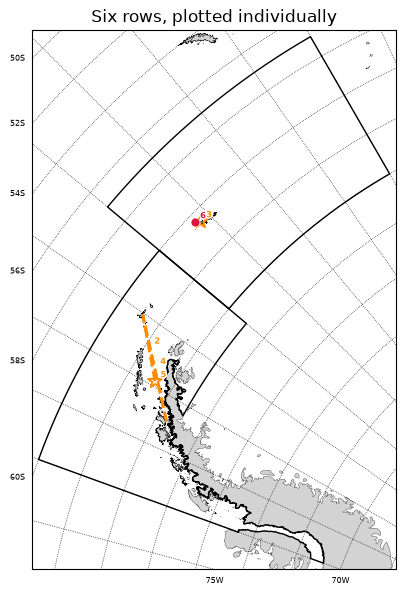

In [7]:
fig, ax = plt.subplots(figsize=(6, 7))
draw_basemap(ax)

sample = fieldwork.head(6)
footnotes = [plot_row(ax, row, n, row["Activity"]) for n, (_, row) in enumerate(sample.iterrows(), start=1)]

ax.set_title("Six rows, plotted individually")
print("\n".join(footnotes))
plt.show()

## Grouping nearby sites

Two situations create visual clutter that grouping fixes:

- Several rows share the exact same `Location` string but no
  coordinates (e.g. cetacean tagging and crabeater seal tagging both
  just say "Gerlache Strait") -- without grouping they'd draw two
  markers stacked exactly on top of each other.
- Several rows are genuinely distinct GPS points a few km apart that are
  close enough, on a map already showing a dozen other things, that
  showing each on its own marker adds clutter rather than information
  (three separate King George Island penguin-tagging sites). These are
  merged via `LOCATION_ALIASES` -- again a manually curated table, not a
  distance-threshold clustering algorithm, so grouping stays predictable
  and doesn't silently change if a new, genuinely distinct site happens
  to land near an existing one.

`group_nearby` combines matching rows into one, averaging coordinates for
clustered precise points and combining their labels ("Penguin Tagging
(3 sites)" if identical, `"; "`-joined otherwise).

In [8]:
LOCATION_ALIASES = {
    "King George Island 1": "King George Island",
    "King George Island 2": "King George Island",
    "King George Island 3": "King George Island",
}


def group_nearby(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    df = df.copy()
    df["_place"] = df["Location"].map(lambda loc: LOCATION_ALIASES.get(loc, loc))
    has_coords = df["Latitude"].notna() & df["Longitude"].notna()
    should_group = ~has_coords | (df["Location"] != df["_place"])

    rows = [row.to_dict() for _, row in df[~should_group].iterrows()]
    for _, sub in df[should_group].groupby("_place", sort=False):
        labels = list(sub[label_col])
        if len(labels) > 1 and len(set(labels)) == 1:
            combined_label = f"{labels[0]} ({len(labels)} sites)"
        else:
            combined_label = "; ".join(labels)
        sub_has_coords = sub["Latitude"].notna() & sub["Longitude"].notna()
        rows.append({
            "Location": sub["_place"].iloc[0],
            label_col: combined_label,
            "Latitude": sub.loc[sub_has_coords, "Latitude"].mean() if sub_has_coords.any() else float("nan"),
            "Longitude": sub.loc[sub_has_coords, "Longitude"].mean() if sub_has_coords.any() else float("nan"),
        })
    return pd.DataFrame(rows)


grouped = group_nearby(fieldwork, "Activity")
print(f"{len(fieldwork)} rows -> {len(grouped)} after grouping")
grouped[grouped["Location"] == "King George Island"]

28 rows -> 24 after grouping


,Location,Longitude,Latitude,Activity,Who,_place
23,King George Island,-58.739423,-62.199574,Penguin Tagging (3 sites),NaN,NaN


## Putting it together: three comparison figures

With `draw_basemap`, `plot_row` and `group_nearby` in hand, a full figure
is: draw the basemap, plot every (grouped) row, lay out the numbered
footnote list as wrapped text, save. `build_figure` below adds one thing
-- faceting into a grid of panels by some grouping column (lead country,
or fieldwork discipline), grouping each panel's rows independently so
e.g. King George Island's three sites collapse within the "Penguin
monitoring & tagging" panel just like they do on their own.

Margins are set explicitly via `fig.subplots_adjust(...)` rather than
`tight_layout()`: `tight_layout` only looks at Axes bounding boxes, and
has no visibility into the footnote text placed via `ax.text(...)` in
axes-fraction coordinates below each Axes -- it reliably warns about this
and won't reserve room for it, so the busiest panel's footnote overflows
into whatever is below it.

In [9]:
def build_figure(df, group_col, group_order, group_labels, label_col, title, grid_shape, figsize, hspace=0.7, bottom_margin=0.12):
    fig, axes = plt.subplots(*grid_shape, figsize=figsize, gridspec_kw={"hspace": hspace})
    for ax, group in zip(axes.flat, group_order):
        draw_basemap(ax)
        ax.set_title(group_labels.get(group, group), fontsize=12, fontweight="bold")

        panel_df = group_nearby(df[df[group_col] == group], label_col)
        footnotes = [plot_row(ax, row, n, row[label_col]) for n, (_, row) in enumerate(panel_df.iterrows(), start=1)]
        wrapped = "\n".join(textwrap.fill(line, width=40, subsequent_indent="   ") for line in footnotes)
        ax.text(0.02, -0.03, wrapped, transform=ax.transAxes, fontsize=6.5, color="black", va="top", ha="left")

    fig.suptitle(title, fontsize=17, fontweight="bold")
    fig.subplots_adjust(left=0.03, right=0.99, top=0.94, bottom=bottom_margin, hspace=hspace, wspace=0.25)
    return fig

### By lead country/collaboration

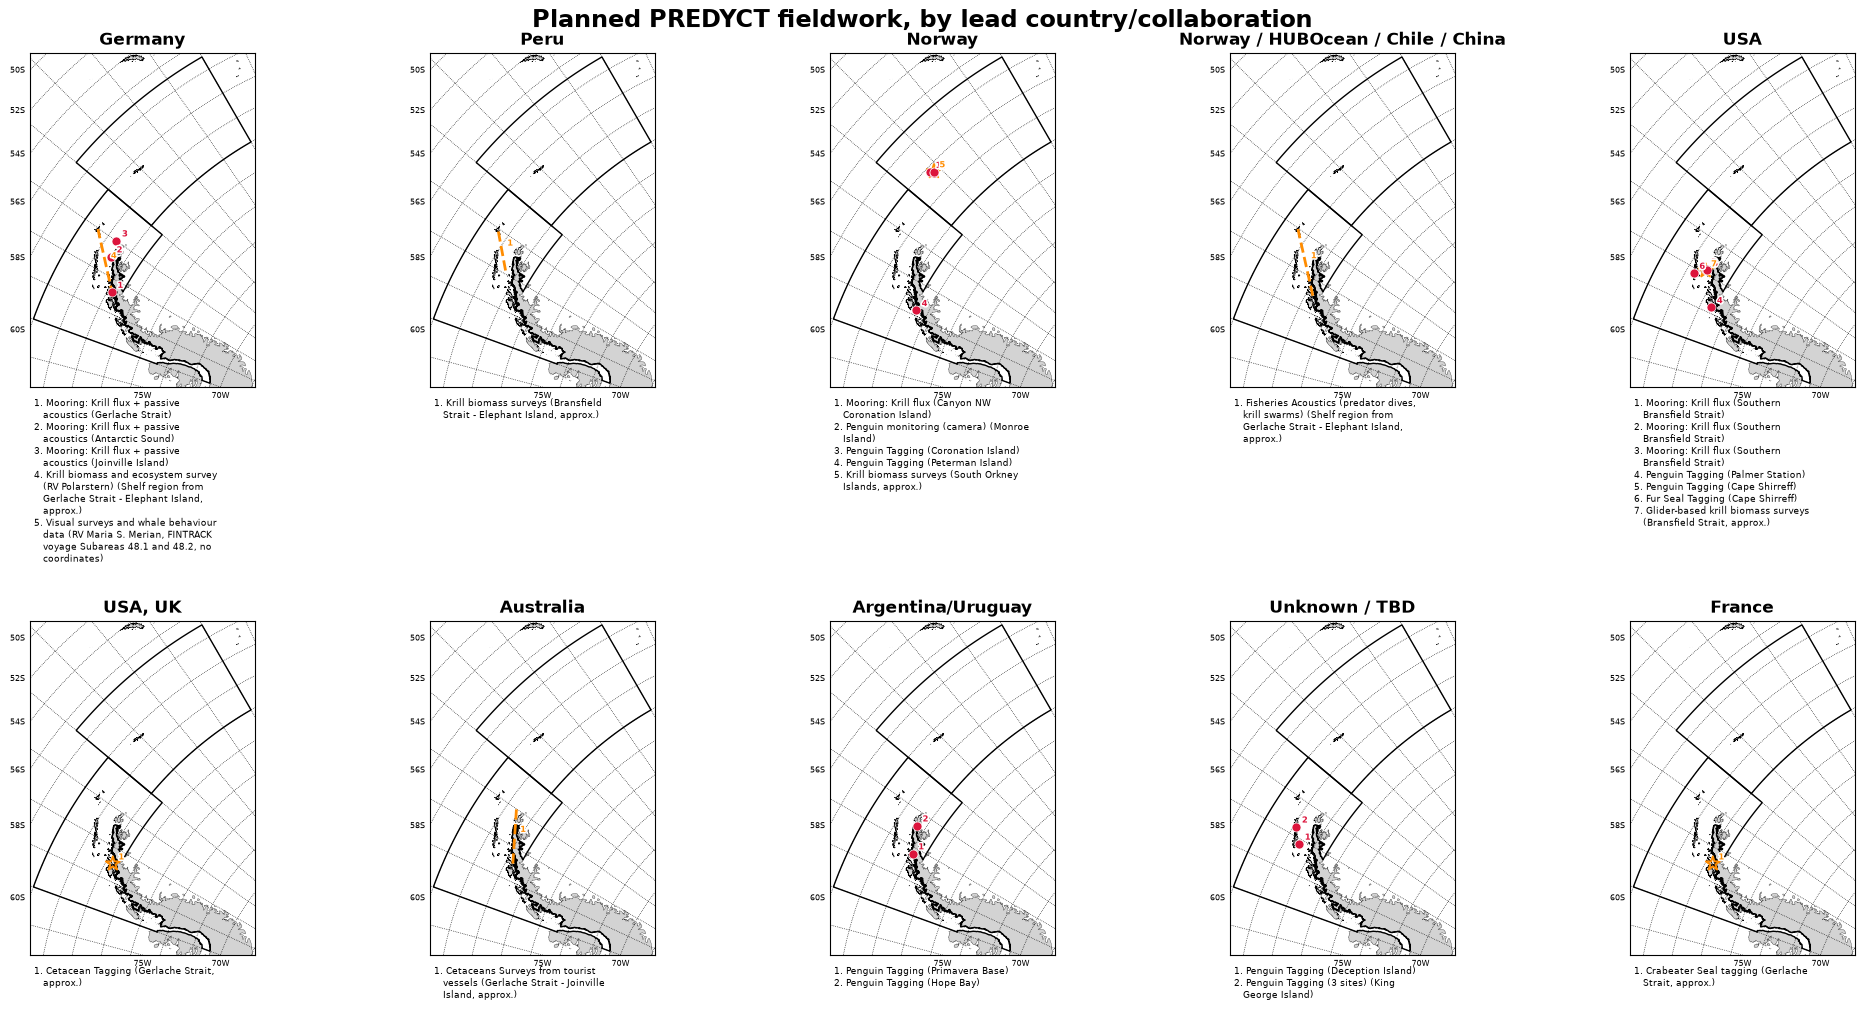

In [10]:
WHO_ORDER = [
    "Germany", "Peru", "Norway", "Norway/HUBOcean, Chile, (China)", "USA",
    "USA, UK", "Australia (Angus Henderson)", "Argentina/Uruguay", "?", "France",
]
WHO_LABELS = {
    "Norway/HUBOcean, Chile, (China)": "Norway / HUBOcean / Chile / China",
    "Australia (Angus Henderson)": "Australia",
    "?": "Unknown / TBD",
}

fig = build_figure(
    fieldwork, group_col="Who", group_order=WHO_ORDER, group_labels=WHO_LABELS,
    label_col="Activity", title="Planned PREDYCT fieldwork, by lead country/collaboration",
    grid_shape=(2, 5), figsize=(20, 11),
)
plt.show()

### By fieldwork type

Same `build_figure`, a different grouping column -- `FieldworkType`,
derived from `Activity` by keyword match. Raising on an unmatched
activity (rather than silently dropping it into an "Other" bucket) means
a new CSV row with wording the keyword list doesn't recognise fails
loudly instead of quietly vanishing from the figure.

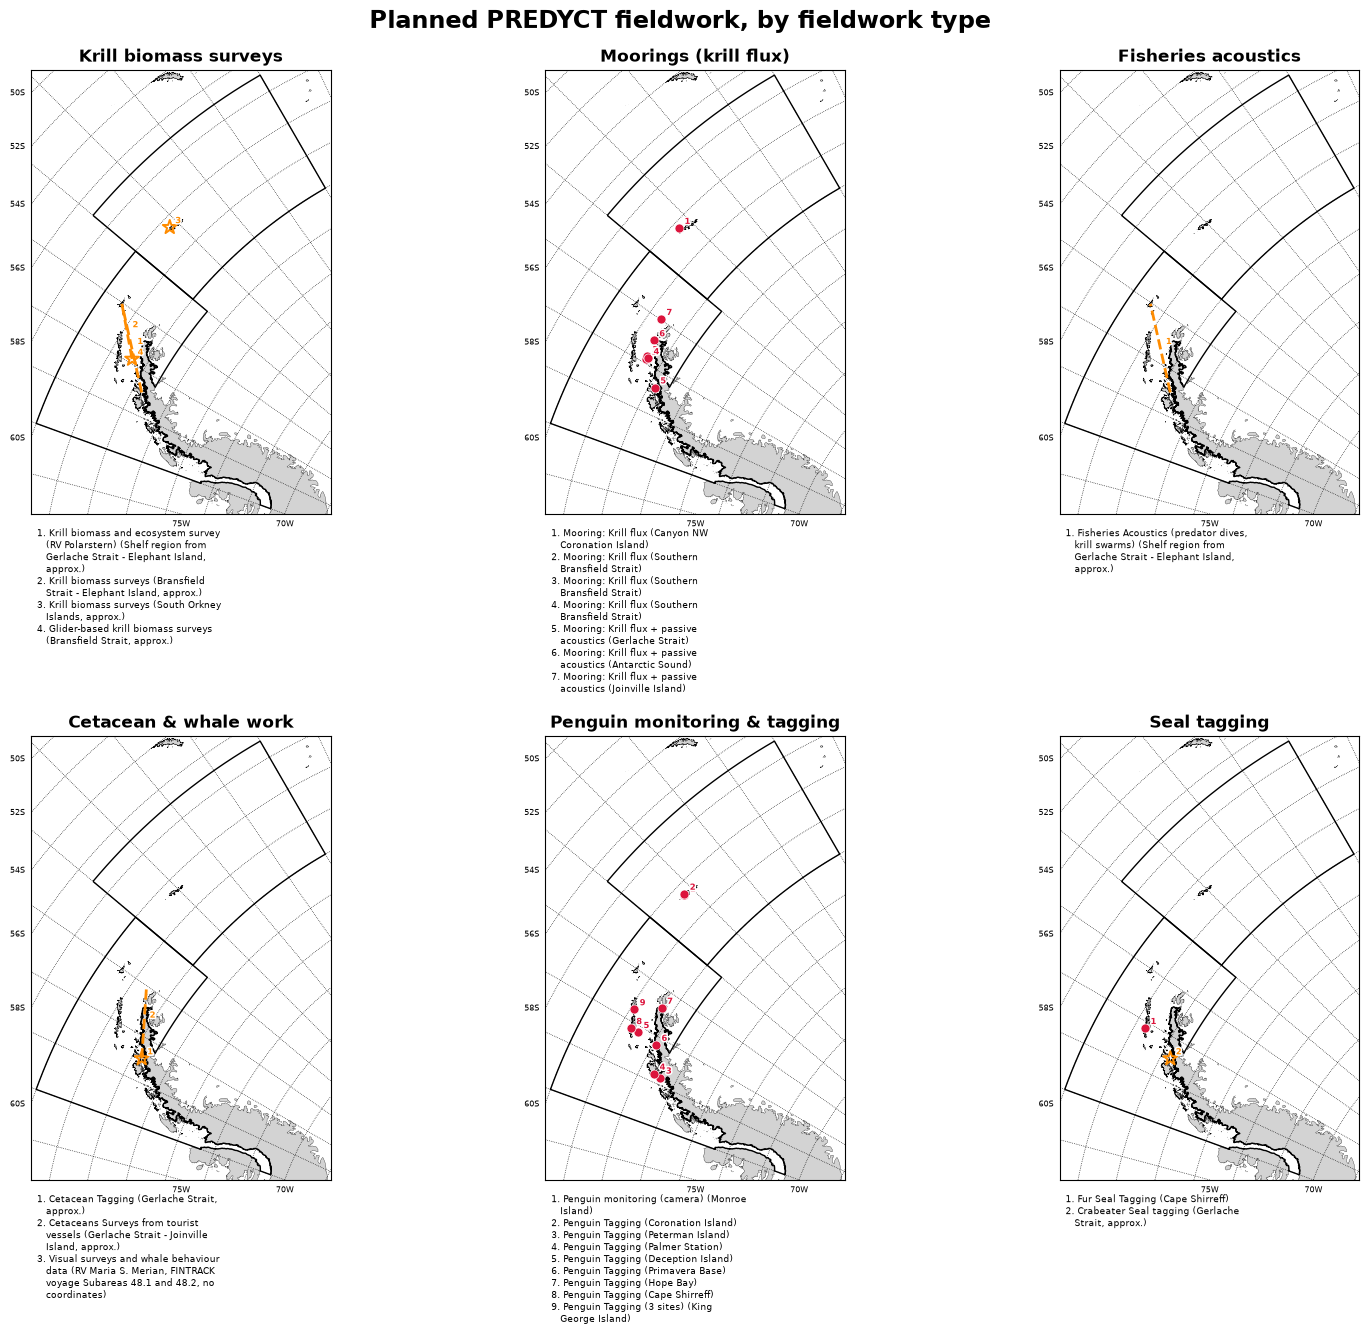

In [11]:
TYPE_ORDER = [
    "Krill biomass surveys", "Moorings (krill flux)", "Fisheries acoustics",
    "Cetacean & whale work", "Penguin monitoring & tagging", "Seal tagging",
]


def categorize(activity: str) -> str:
    a = activity.lower()
    if "mooring" in a:
        return "Moorings (krill flux)"
    if "krill biomass" in a:
        return "Krill biomass surveys"
    if "fisheries acoustics" in a:
        return "Fisheries acoustics"
    if "penguin" in a:
        return "Penguin monitoring & tagging"
    if "seal" in a:
        return "Seal tagging"
    if "cetacean" in a or "whale" in a:
        return "Cetacean & whale work"
    return "Other"


fieldwork_typed = fieldwork.copy()
fieldwork_typed["FieldworkType"] = fieldwork_typed["Activity"].map(categorize)
unmatched = fieldwork_typed[fieldwork_typed["FieldworkType"] == "Other"]
if not unmatched.empty:
    raise ValueError(f"Uncategorised activities, update categorize(): {unmatched['Activity'].tolist()}")

fig = build_figure(
    fieldwork_typed, group_col="FieldworkType", group_order=TYPE_ORDER, group_labels={},
    label_col="Activity", title="Planned PREDYCT fieldwork, by fieldwork type",
    grid_shape=(2, 3), figsize=(15, 15), hspace=0.5, bottom_margin=0.2,
)
plt.show()

### Summary: where does effort concentrate?

The two faceted figures above are good for comparing *across* a
dimension (country, or discipline) but bad at showing overlap *within* a
place -- each activity sits in its own panel, so there's no single view
showing that, say, Gerlache Strait has both cetacean tagging and
crabeater seal tagging planned at once.

An early prototype tried encoding fieldwork type as marker colour on one
combined map -- it didn't work: two different-coloured translucent
markers stacked at the same point optically blend into a colour matching
neither legend entry, which is actively misleading rather than merely
unclear. The fix isn't a plotting trick, it's the same grouping already
built above -- activities sharing a place get listed together under one
marker, and the caption explains what's there, rather than the marker
colour trying to.

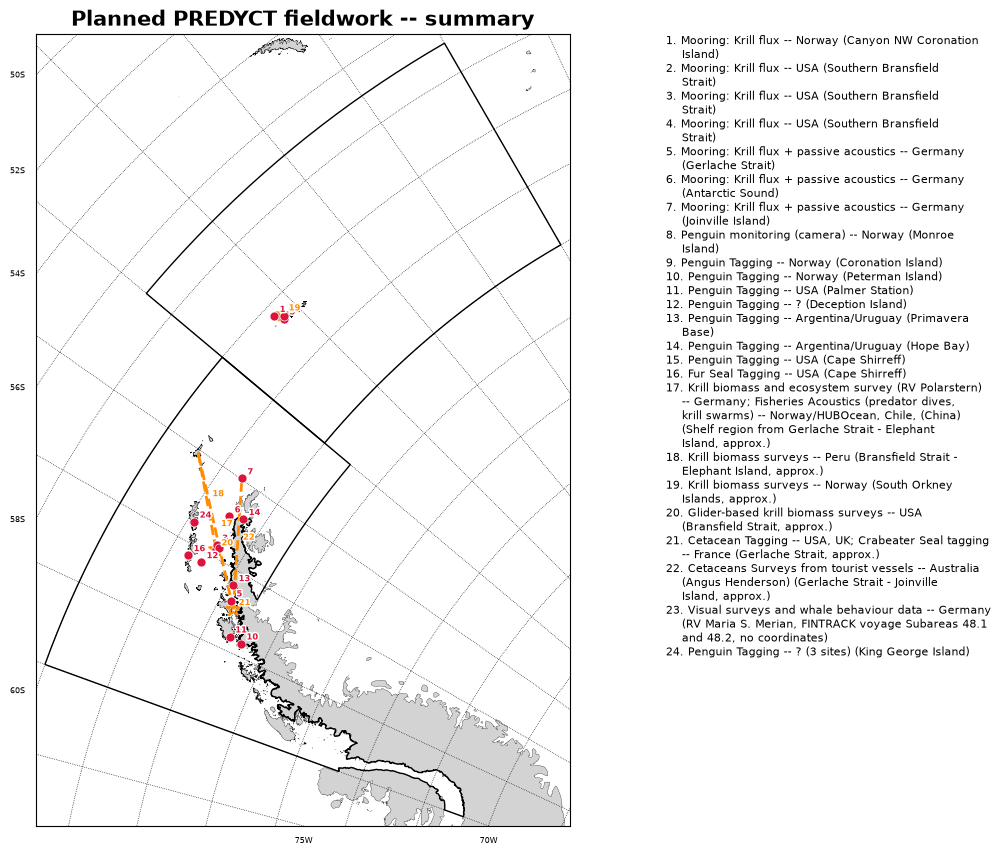

In [12]:
fieldwork_labelled = fieldwork.copy()
fieldwork_labelled["Label"] = fieldwork_labelled["Activity"] + " -- " + fieldwork_labelled["Who"]
summary_df = group_nearby(fieldwork_labelled, "Label")

fig = plt.figure(figsize=(11, 9))
ax = fig.add_axes((0.03, 0.06, 0.62, 0.88))
draw_basemap(ax)
ax.set_title("Planned PREDYCT fieldwork -- summary", fontsize=15, fontweight="bold")

footnotes = [plot_row(ax, row, n, row["Label"]) for n, (_, row) in enumerate(summary_df.iterrows(), start=1)]
wrapped = "\n".join(textwrap.fill(line, width=55, subsequent_indent="    ") for line in footnotes)
fig.text(0.67, 0.94, wrapped, fontsize=8, va="top", ha="left")
plt.show()

## Where this goes from here

This notebook duplicates (for teaching purposes) the logic that lives in
`fieldwork_common.py` and is actually used by
`make_subarea48_fieldwork_by_country.py`,
`make_subarea48_fieldwork_by_type.py` and
`make_subarea48_fieldwork_summary.py` to produce the committed figures in
`output/`. Those scripts add PDF output (`figure_io.save_fig`) and pull
`WHO_ORDER`/`TYPE_ORDER`/captions out into each script -- see the
[README](README.md) for the full, current figures.